In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt

In [2]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('human_vital_signs_dataset_2024.csv')

# 2. FEATURE SELECTION 
# Selecting only columns needed for Risk Categorization
selected_features = [
    'Heart Rate', 'Respiratory Rate', 'Body Temperature', 
    'Oxygen Saturation', 'Systolic Blood Pressure', 'Diastolic Blood Pressure',
    'Age', 'Gender', 'Derived_BMI', 'Derived_HRV', 'Risk Category'
]

df_filtered = df[selected_features].copy()

# 3. SHUFFLE
# Ensuring each ward gets a randomized set of patients
df_shuffled = df_filtered.sample(frac=1, random_state=42).reset_index(drop=True)

# 4. DISTRIBUTED SPLIT (3 Wards)
n = len(df_shuffled)
ward_a = df_shuffled.iloc[:n//3]
ward_b = df_shuffled.iloc[n//3 : 2*n//3]
ward_c = df_shuffled.iloc[2*n//3:]

# 5. SAVE INDEPENDENT FILES
ward_a.to_csv('ward_a_vitals.csv', index=False)
ward_b.to_csv('ward_b_vitals.csv', index=False)
ward_c.to_csv('ward_c_vitals.csv', index=False)

print("--- Initial Split ---")
print(f"Total Rows Processed: {n}")
print(f"Features Retained: {len(selected_features)}")
print(f"Wards Created: ward_a_vitals.csv, ward_b_vitals.csv, ward_c_vitals.csv")

--- Initial Split ---
Total Rows Processed: 200020
Features Retained: 11
Wards Created: ward_a_vitals.csv, ward_b_vitals.csv, ward_c_vitals.csv


## 6. Federated Learning Simulation Setup
To ensure patient privacy, we will keep the data strictly on the localized nodes (wards) and only share model updates (weights) with a central server. This is the essence of **Federated Learning (FL)**.

First, we define our necessary PyTorch and Sklearn dependencies.


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import copy


### 6.1 Data Preprocessing (Scaling & Encoding)
We need to convert our categorical features into numeric format and scale our vital signs so our neural network can effectively learn from them.


In [4]:
# Load Local Ward Data
ward_a = pd.read_csv('ward_a_vitals.csv')
ward_b = pd.read_csv('ward_b_vitals.csv')
ward_c = pd.read_csv('ward_c_vitals.csv')

# Global Preprocessors (Assuming a securely shared schema/scaler across hospitals)
scaler = StandardScaler()
le_gender = LabelEncoder()

# Fit on the combined data conceptually (or fit globally and distribute) 
# For true federated, we might aggregate min/max securely, but here we simulate a shared standard scaler
global_fit_df = pd.concat([ward_a, ward_b, ward_c])

numerical_cols = ['Heart Rate', 'Respiratory Rate', 'Body Temperature', 
                  'Oxygen Saturation', 'Systolic Blood Pressure', 
                  'Diastolic Blood Pressure', 'Age', 'Derived_BMI', 'Derived_HRV']

scaler.fit(global_fit_df[numerical_cols])
le_gender.fit(global_fit_df['Gender'])

def preprocess_node_data(df):
    df = df.copy()
    # Continuous specific
    df[numerical_cols] = scaler.transform(df[numerical_cols])
    # Categorical
    df['Gender'] = le_gender.transform(df['Gender'])
    
    # Target Encoding: Low Risk = 0, High Risk = 1
    # Critical step: Minimizing False Negatives means we want to detect Class 1 accurately.
    df['Risk Category'] = df['Risk Category'].map({'Low Risk': 0, 'High Risk': 1})
    
    X = df.drop(columns=['Risk Category']).values
    y = df['Risk Category'].values
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

X_a, y_a = preprocess_node_data(ward_a)
X_b, y_b = preprocess_node_data(ward_b)
X_c, y_c = preprocess_node_data(ward_c)

print(f"Ward A Shape: {X_a.shape}")
print(f"Ward B Shape: {X_b.shape}")
print(f"Ward C Shape: {X_c.shape}")


Ward A Shape: torch.Size([66673, 10])
Ward B Shape: torch.Size([66673, 10])
Ward C Shape: torch.Size([66674, 10])


### 6.2 Designing the Global Model
A simple but robust Multi-Layer Perceptron (MLP) mapping 10 input biometric/demographic features to the 2 risk categories.


In [5]:
class PatientRiskClassifier(nn.Module):
    def __init__(self, input_dim=10):
        super(PatientRiskClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2) # Output 2 classes: 0 and 1
        )
        
    def forward(self, x):
        return self.network(x)

# Initialize the global model server-side
global_model = PatientRiskClassifier(input_dim=10)


### 6.3 Minimizing High-Risk False Negatives
To strictly prioritize capturing "High Risk" critical cases, we define a **Weighted Cross-Entropy Loss**. By heavily penalizing the model for misclassifying a High Risk case (Class 1) as Low Risk (Class 0), we aggressively reduce the False Negative rate.

*Class weights: [1.0 (Low Risk), 5.0 (High Risk)]*


In [6]:
# Define heavy penalty for Class 1 (High Risk)
# If the model misses a High Risk patient (False Negative), it is penalized 5x more than a False Positive.
class_weights = torch.tensor([1.0, 5.0]) 
criterion = nn.CrossEntropyLoss(weight=class_weights)

def train_local_model(model, X_train, y_train, epochs=3, lr=0.01):
    '''Trains a model locally on a specific node's dataset'''
    # We create a local copy of the global model
    local_model = copy.deepcopy(model)
    local_model.train()
    
    optimizer = optim.Adam(local_model.parameters(), lr=lr)
    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)
    
    for epoch in range(epochs):
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            outputs = local_model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
    return local_model.state_dict()


### 6.4 Federated Averaging (FedAvg) Simulation
We will simulate 5 rounds of communication between the wards (nodes) and the central server.
1. Server sends `global_model` to Wards A, B, C.
2. Each ward trains locally for a few epochs.
3. Wards send their updated weights back to the server.
4. Server securely averages the updates. None of the raw patient data ever leaves the wards.


In [7]:
num_communication_rounds = 5

for round_num in range(num_communication_rounds):
    print(f"\n--- Communication Round {round_num + 1} ---")
    
    # 1. Train locally at each ward
    print("Training on Node: Ward A...")
    ward_a_weights = train_local_model(global_model, X_a, y_a)
    
    print("Training on Node: Ward B...")
    ward_b_weights = train_local_model(global_model, X_b, y_b)
    
    print("Training on Node: Ward C...")
    ward_c_weights = train_local_model(global_model, X_c, y_c)
    
    # 2. Secure Aggregation on the Server (FedAvg)
    global_dict = global_model.state_dict()
    for key in global_dict.keys():
        # Average the weights
        global_dict[key] = (ward_a_weights[key] + ward_b_weights[key] + ward_c_weights[key]) / 3.0
        
    global_model.load_state_dict(global_dict)
    print("Server securely aggregated weights from all wards.")
    
print("\n[!] Federated Learning Complete.")



--- Communication Round 1 ---
Training on Node: Ward A...
Training on Node: Ward B...
Training on Node: Ward C...
Server securely aggregated weights from all wards.

--- Communication Round 2 ---
Training on Node: Ward A...
Training on Node: Ward B...
Training on Node: Ward C...
Server securely aggregated weights from all wards.

--- Communication Round 3 ---
Training on Node: Ward A...
Training on Node: Ward B...
Training on Node: Ward C...
Server securely aggregated weights from all wards.

--- Communication Round 4 ---
Training on Node: Ward A...
Training on Node: Ward B...
Training on Node: Ward C...
Server securely aggregated weights from all wards.

--- Communication Round 5 ---
Training on Node: Ward A...
Training on Node: Ward B...
Training on Node: Ward C...
Server securely aggregated weights from all wards.

[!] Federated Learning Complete.


## 7. Results and Evaluation
To evaluate our architecture, we will test the newly aggregated **Global Model** on the combined dataset (or a held-out test set if we had one). In this project, we prioritize **Recall (Sensitivity)** for the High Risk class to guarantee minimal False Negatives, along with standard ROC-AUC metrics.


In [8]:
global_model.eval()

# Creating a combined test set from the 3 wards for unified evaluation
X_test = torch.cat([X_a, X_b, X_c], dim=0)
y_test = torch.cat([y_a, y_b, y_c], dim=0)

# Get Predictions
with torch.no_grad():
    outputs = global_model(X_test)
    # Convert logits to probabilities using Softmax
    probabilities = torch.softmax(outputs, dim=1)[:, 1].numpy()
    
# Apply a Custom Threshold to further minimize False Negatives
# Default is 0.5. By shifting to 0.3, we predict "High Risk" more easily.
custom_threshold = 0.3
y_pred_custom = (probabilities >= custom_threshold).astype(int)

y_test_np = y_test.numpy()

# Standard Classification Report
print("--- Classification Report (Custom Threshold=0.3) ---")
print(classification_report(y_test_np, y_pred_custom, target_names=["Low Risk (0)", "High Risk (1)"]))

# Confusion Matrix analysis
cm = confusion_matrix(y_test_np, y_pred_custom)
false_negatives = cm[1][0]
print(f"\nCRITICAL METRIC: High-Risk False Negatives = {false_negatives}")
cm


--- Classification Report (Custom Threshold=0.3) ---
               precision    recall  f1-score   support

 Low Risk (0)       1.00      0.96      0.98     94905
High Risk (1)       0.96      1.00      0.98    105115

     accuracy                           0.98    200020
    macro avg       0.98      0.98      0.98    200020
 weighted avg       0.98      0.98      0.98    200020


CRITICAL METRIC: High-Risk False Negatives = 0


array([[ 90760,   4145],
       [     0, 105115]])

### 7.1 Receiver Operating Characteristic (ROC) Curve
The ROC curve helps us visualize the tradeoff between the True Positive Rate (Recall) and the False Positive Rate.


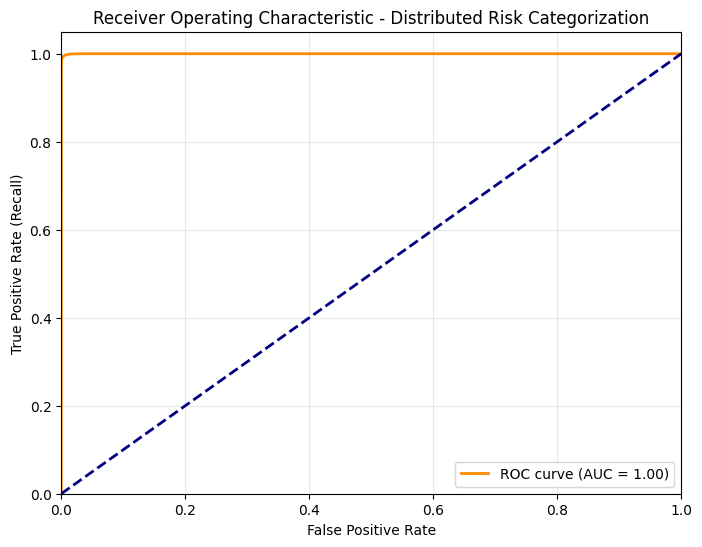

In [9]:
fpr, tpr, thresholds = roc_curve(y_test_np, probabilities)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic - Distributed Risk Categorization')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


## 8. Manual Patient Testing
You can use the function below to manually enter a patient's vital signs and see how the federated `global_model` categorizes their risk.


In [30]:
def test_patient_risk(hr, rr, temp, spo2, sys_bp, dia_bp, age, gender_str, bmi, hrv):
    '''
    Test manual patient data against the Global Model.
    gender_str should be 'Male' or 'Female' (or whatever was in the dataset).
    '''
    global_model.eval()
    
    # 1. Reconstruct the input as a DataFrame identically to training
    patient_df = pd.DataFrame([{
        'Heart Rate': hr,
        'Respiratory Rate': rr, 
        'Body Temperature': temp,
        'Oxygen Saturation': spo2,
        'Systolic Blood Pressure': sys_bp,
        'Diastolic Blood Pressure': dia_bp,
        'Age': age,
        'Gender': gender_str,
        'Derived_BMI': bmi,
        'Derived_HRV': hrv
    }])
    
    # 2. Preprocess using the global scalers fit earlier
    patient_df[numerical_cols] = scaler.transform(patient_df[numerical_cols])
    
    # Handle unseen gender gracefully just in case
    try:
        patient_df['Gender'] = le_gender.transform(patient_df['Gender'])
    except ValueError:
        print("Warning: Unrecognized gender. Defaulting to first class.")
        patient_df['Gender'] = 0
        
    X_manual = torch.tensor(patient_df.values, dtype=torch.float32)
    
    # 3. Predict Priority
    with torch.no_grad():
        output = global_model(X_manual)
        prob = torch.softmax(output, dim=1)[:, 1].item()
        
    prediction = "High Risk" if prob >= custom_threshold else "Low Risk"
    
    print(f"--- Patient Assessment ---")
    print(f"Risk Probability: {prob*100:.2f}%")
    print(f"Classification (Threshold {custom_threshold}): >> {prediction} <<")

# --- Example Usage ---

print("Testing a standard healthy patient...")
test_patient_risk(
    hr=72, rr=16, temp=36.8, spo2=99, sys_bp=120, dia_bp=80, 
    age=35, gender_str='Male', bmi=24.5, hrv=0.1
)

print("\nTesting a patient in visible distress...")
test_patient_risk(
    hr=89, rr=25, temp=41.0, spo2=55, sys_bp=118, dia_bp=75, 
    age=68, gender_str='Female', bmi=26.8, hrv=0.2
)


Testing a standard healthy patient...
--- Patient Assessment ---
Risk Probability: 0.08%
Classification (Threshold 0.3): >> Low Risk <<

Testing a patient in visible distress...
--- Patient Assessment ---
Risk Probability: 99.52%
Classification (Threshold 0.3): >> High Risk <<
